In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.ndimage import uniform_filter1d
from scipy.ndimage import percentile_filter
import nrrd
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from skimage.draw import disk

In [2]:
region_names_modifications = pd.read_excel('/Volumes/raid_126TB/H2B_GCaMP6s_new/Region_names_zbrain.xlsx',
                                           sheet_name='Sheet1', header=0, usecols='A,B,C,D,E')

In [3]:
regions_info = region_names_modifications[region_names_modifications['Include'] == True]

short_to_orig = dict(zip(regions_info['Short Names'], regions_info['Original Names']))
orig_to_short = dict(zip(regions_info['Original Names'], regions_info['Short Names']))

regions_info

,Original Names,Short Names,Structure,MECE,Include
0,Diencephalon -,Diencephalon,Diencephalon,False,True
1,Diencephalon - Anterior group of the posterior...,Anterior group of the posterior tubercular vma...,Diencephalon,False,True
2,Diencephalon - Anterior preoptic dopaminergic ...,Anterior preoptic dopaminergic cluster,Diencephalon,False,True
3,Diencephalon - Anterior pretectum cluster of v...,Anterior pretectum cluster of vmat2 Neurons,Diencephalon,False,True
4,Diencephalon - Caudal Hypothalamus,Caudal Hypothalamus,Diencephalon,True,True
...,...,...,...,...,...
289,Telencephalon - Subpallial dopaminergic cluster,Subpallial dopaminergic cluster,Telencephalon,False,True
290,Telencephalon - Subpallium,Subpallium,Telencephalon,True,True
291,Telencephalon - Telencephalic Migrated Area 4 ...,Telencephalic Migrated Area 4 (M4),Telencephalon,False,True
292,Telencephalon - Vglut2 rind,Vglut2 rind,Telencephalon,False,True


**Load one exemplary fish**

In [4]:
root_path   = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected'
compound    = 'PTZ'
fish_number = '11'   # used for manuscript: fish11_PTZ, fish01_control

cells = pd.read_csv(f'{root_path}/neurons/analysis/fish{fish_number}_{compound}_cells_included_regions_zbrain.csv')
cells['z'] = cells['z'].round(0).astype(int)   # integer planes
cells.shape

(33000, 300)

In [5]:
# dF/F with fixed pre-baseline 
# rows are aligned by position with cells (row i of dFF == row i of cells)
dFF = pd.read_csv(f'{root_path}/neurons/analysis/fish{fish_number}_{compound}_dFF_included_regions_zbrain.csv',
                  index_col=0)
assert dFF.shape[0] == cells.shape[0], 'cells and dFF must have the same number of rows'
dff_arr = dFF.to_numpy()  # (n_neurons, n_timepoints)
n_timepoints = dff_arr.shape[1]
dff_arr.shape

(33000, 1109)

**Select random neurons from chosen regions**

In [6]:
def select_random_neurons(cells, dff_arr, regions_short, short_to_orig,
                           n_per_region=5, seed=0):
    
    rng = np.random.default_rng(seed)
    records = []
    
    for short in regions_short:
        orig = short_to_orig.get(short, short)
        if orig not in cells.columns:
            print(f'region "{short}" ({orig}) not in cells columns')
            continue   
            
        pos = np.where(cells[orig].astype(bool).to_numpy())[0]        
        if pos.size == 0:
            print(f'region "{short}" has no neurons')
            continue
            
        n = min(n_per_region, pos.size)
        if n < n_per_region:
            print(f'region "{short}" only has {pos.size} neurons, taking {n}')
            
        for p in rng.choice(pos, size=n, replace=False):
            p = int(p)            
            records.append({'pos': p,
                            'region_short': short,
                            'region_orig': orig,
                            'x': cells.iloc[p]['x'],
                            'y': cells.iloc[p]['y'],
                            'z': cells.iloc[p]['z']})
    sel_df = pd.DataFrame(records)
    traces_sel = dff_arr[sel_df['pos'].to_numpy()]
    
    return sel_df, traces_sel

In [7]:
# chosen sample for fish11_PTZ
# select regions with short names
regions_for_neurons = ['Pallium', 
                       'Subpallium',
                       'Olfactory Bulb',
                       'Habenula',
                       'Pineal',
                       'Posterior Tuberculum',
                       'Tectum Stratum Periventriculare',
                       'Tegmentum',
                       'Torus Longitudinalis',
                       'Cerebellum',
                       'Locus Coeruleus',
                       'Rhombomere 7']
n_per_region        = 1
seed                = 1

sel_df, traces_sel = select_random_neurons(
    cells, dff_arr, regions_for_neurons, short_to_orig,
    n_per_region=n_per_region, seed=seed)

sel_df = sel_df.reindex(index=sel_df.index[::-1])
sel_df

,pos,region_short,region_orig,x,y,z
11,23732,Rhombomere 7,Rhombencephalon - Rhombomere 7,224.0,854.0,103
10,13376,Locus Coeruleus,Rhombencephalon - Locus Coreuleus,418.0,676.0,64
9,21531,Cerebellum,Rhombencephalon - Cerebellum,229.0,626.0,95
8,26371,Torus Longitudinalis,Mesencephalon - Torus Longitudinalis,313.0,373.0,107
7,17190,Tegmentum,Mesencephalon - Tegmentum,262.0,506.0,86
6,29824,Tectum Stratum Periventriculare,Mesencephalon - Tectum Stratum Periventriculare,255.0,591.0,116
5,1405,Posterior Tuberculum,Diencephalon - Posterior Tuberculum,287.0,447.0,36
4,26201,Pineal,Diencephalon - Pineal,317.0,336.0,106
3,28187,Habenula,Diencephalon - Habenula,261.0,300.0,110
2,10363,Olfactory Bulb,Telencephalon - Olfactory Bulb,342.0,134.0,70


In [ ]:
# chosen sample for fish01_control
regions_for_neurons = ['Telencephalon', 
                       'Diencephalon',
                       'Mesencephalon',
                       'Rhombencephalon']
n_per_region        = 3
seed                = 2

sel_df, traces_sel = select_random_neurons(
    cells, dff_arr, regions_for_neurons, short_to_orig,
    n_per_region=n_per_region, seed=seed)

sel_df = sel_df.reindex(index=sel_df.index[::-1])
sel_df

In [8]:
# Colour each neuron by its major brain division, using same colors as in other analysis plots

major_region_colors = {
    'Telencephalon':   'tab:red',
    'Diencephalon':    'orange',
    'Mesencephalon':   'mediumseagreen',
    'Rhombencephalon': 'dodgerblue',
}

def major_region_of(original_name):
    return str(original_name).split('-')[0].strip()

sel_df['major_region'] = sel_df['region_orig'].map(major_region_of)

# legend order: canonical major-division order, keeping only those actually present
major_order = ['Telencephalon', 'Diencephalon', 'Mesencephalon', 'Rhombencephalon']
present_majors = [m for m in major_order if m in set(sel_df['major_region'])]

# warn if a region's prefix didn't match one of the four majors
unknown = sorted(set(sel_df.loc[~sel_df['major_region'].isin(major_region_colors),
                                'major_region']))
if unknown:
    print('major regions without an assigned colour (will plot gray):', unknown)

sel_df[['region_short', 'region_orig', 'major_region']]

,region_short,region_orig,major_region
11,Rhombomere 7,Rhombencephalon - Rhombomere 7,Rhombencephalon
10,Locus Coeruleus,Rhombencephalon - Locus Coreuleus,Rhombencephalon
9,Cerebellum,Rhombencephalon - Cerebellum,Rhombencephalon
8,Torus Longitudinalis,Mesencephalon - Torus Longitudinalis,Mesencephalon
7,Tegmentum,Mesencephalon - Tegmentum,Mesencephalon
6,Tectum Stratum Periventriculare,Mesencephalon - Tectum Stratum Periventriculare,Mesencephalon
5,Posterior Tuberculum,Diencephalon - Posterior Tuberculum,Diencephalon
4,Pineal,Diencephalon - Pineal,Diencephalon
3,Habenula,Diencephalon - Habenula,Diencephalon
2,Olfactory Bulb,Telencephalon - Olfactory Bulb,Telencephalon


**Stacked line plot of individual traces**

In [9]:
# x-axis ticks in minutes (one frame every 3.25 s)
t = np.arange(n_timepoints)
minutes = np.round((len(t) * 3.25) / 60)
x_ticklabels = np.arange(0, int(minutes) + 1, 10)
x_ticks = np.arange(0, len(t) + 2, 185)   # 185 frames = 10 min

# stimulus markers
stim_lines = [185, 370, 647, 832]
stim_spans = [(185, 370), (647, 832)]

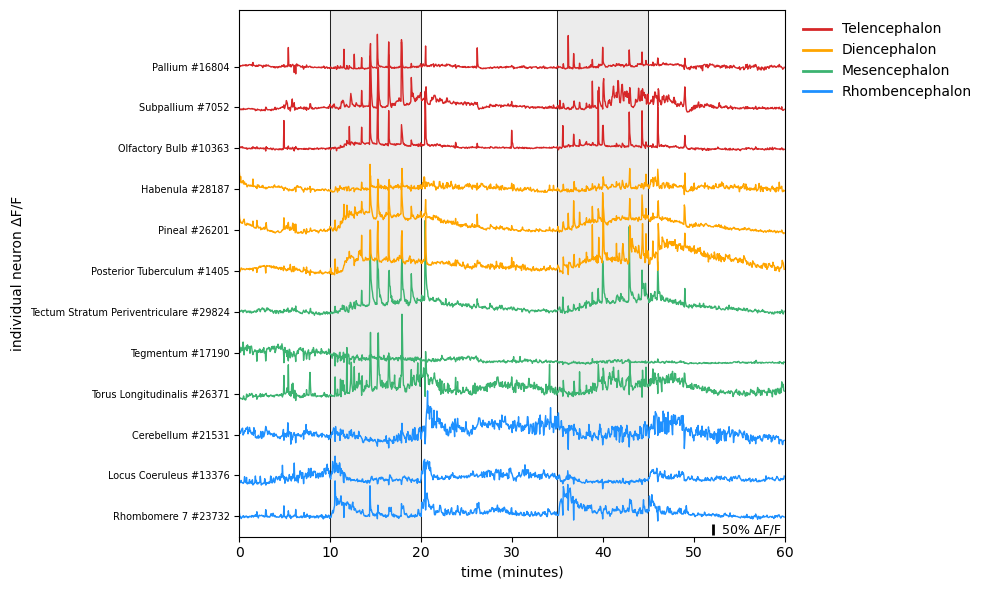

In [10]:
offset_step = 2.0   # vertical spacing between neurons, tune to dF/F amplitude (1 for Tricaine, 2 for PTZ)
smooth      = 1     # temporal smoothing window (frames), set 1 to disable

# vertical scalebar indicating dF/F height (in the same units as the traces)
scalebar_dff   = 0.5  # bar length, e.g. 0.5 == 50% dF/F
scalebar_label = f'{scalebar_dff:.0%} ΔF/F'

n_sel = traces_sel.shape[0]
bottom_pad = 1.0
vertical_offsets = np.arange(n_sel) * offset_step + bottom_pad

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(n_sel):
    m = sel_df['major_region'].iloc[i]
    color = major_region_colors.get(m, 'gray')   # color by major brain region
    trace = uniform_filter1d(traces_sel[i], size=smooth) if smooth > 1 else traces_sel[i]
    ax.plot(t, trace + vertical_offsets[i], color=color, linewidth=1)

# stimulus markers
if stim_spans:
    for x0, x1 in stim_spans:
        ax.axvspan(x0, x1, color='gray', alpha=0.15, zorder=0)
if stim_lines:
    for x in stim_lines:
        ax.axvline(x=x, color='black', linewidth=0.6, zorder=1)

ax.set_xlabel('time (minutes)')
ax.set_xlim(0, t[-1])
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels)

# label each line with the region and neuron row index
ax.set_ylim(bottom=0)
ax.set_yticks(vertical_offsets)
ax.set_yticklabels([f"{sel_df['region_short'].iloc[i]} #{sel_df['pos'].iloc[i]}"
                    for i in range(n_sel)], fontsize=7)
ax.set_ylabel('individual neuron ΔF/F')

# one legend entry per major brain region
handles = [Line2D([0], [0], color=major_region_colors[m], lw=2, label=m)
           for m in present_majors]
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1.0), loc='upper left',
          frameon=False)

plt.margins(0, 0.01)

# dF/F scalebar (bottom-right)
# y-axis is in dF/F units, so a vertical bar of height `scalebar_dff` represents that dF/F.
ymin, ymax = ax.get_ylim()
sb_x = t[-1] * 0.87  # horizontal position
sb_bottom = 0.1      # just above the bottom axis
ax.plot([sb_x, sb_x], [sb_bottom, sb_bottom + scalebar_dff],
        color='black', linewidth=2, solid_capstyle='butt', clip_on=False)
ax.text(sb_x + t[-1] * 0.015, sb_bottom + scalebar_dff / 2, scalebar_label,
        va='center', ha='left', fontsize=9)

plt.tight_layout()


**Without y-labels for manuscript figure**

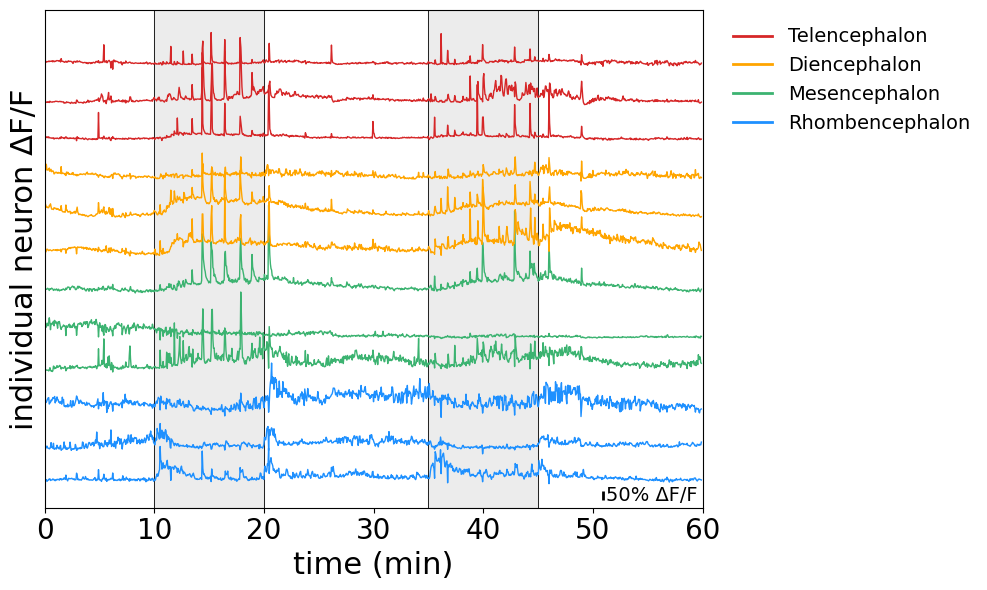

In [11]:
offset_step = 2.0  # vertical spacing between neurons, tune to your dF/F amplitude (1 for Tricaine, 2 for PTZ)
smooth      = 1    # temporal smoothing window (frames), set 1 to disable

# vertical scalebar indicating dF/F height (in the same units as the traces)
scalebar_dff   = 0.5  # bar length, e.g. 0.3 == 30% dF/F
scalebar_label = f'{scalebar_dff:.0%} ΔF/F'

n_sel = traces_sel.shape[0]
bottom_pad = 1.0
vertical_offsets = np.arange(n_sel) * offset_step + bottom_pad

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(n_sel):
    m = sel_df['major_region'].iloc[i]
    color = major_region_colors.get(m, 'gray')  # color by major brain region
    trace = uniform_filter1d(traces_sel[i], size=smooth) if smooth > 1 else traces_sel[i]
    ax.plot(t, trace + vertical_offsets[i], color=color, linewidth=1)

# stimulus markers
if stim_spans:
    for x0, x1 in stim_spans:
        ax.axvspan(x0, x1, color='gray', alpha=0.15, zorder=0)
if stim_lines:
    for x in stim_lines:
        ax.axvline(x=x, color='black', linewidth=0.6, zorder=1)

ax.set_xlabel('time (min)', fontsize=22)
ax.set_xlim(0, t[-1])
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticklabels, fontsize=20)

ax.set_ylim(bottom=-0.5)  # below zero to make space for the dF/F scalebar
ax.set_yticks([])
ax.set_ylabel('individual neuron ΔF/F', fontsize=22)

# one legend entry per major brain region
handles = [Line2D([0], [0], color=major_region_colors[m], lw=2, label=m)
           for m in present_majors]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.0), loc='upper left',
          fontsize=14, frameon=False)

plt.margins(0, 0.01)

# dF/F scalebar (bottom-right)
# y-axis is in dF/F units, so a vertical bar of height scalebar_dff represents that dF/F
sb_x      = t[-1] * 0.85  # horizontal position
sb_bottom = -0.1  # scalebar position, just below first neuron trace, and thats why I set ylim to -0.5
ax.plot([sb_x, sb_x], [sb_bottom, sb_bottom + scalebar_dff],
        color='black', linewidth=2, solid_capstyle='butt', clip_on=False)
ax.text(sb_x + t[-1] * 0.005, sb_bottom + scalebar_dff / 2, scalebar_label,
        va='center', ha='left', fontsize=14)

plt.tight_layout()

**Selected cells on max-projection of reference brain**

In [12]:
def load_nrrd(path):
    vol, header = nrrd.read(path)
    vol = np.asarray(vol).T
    return vol, header

def project(vol, axis=0, mode='max'):
    if mode == 'max':
        return np.max(vol, axis=axis)
    if mode == 'mean':
        return np.mean(vol, axis=axis)

In [13]:
def overlay_regions_on_brain(
    brain_2d,
    region_masks_2d_dict,
    region_colors_dict,
    color_overlay=True,
    alpha=0.3,
    outline=False,
    outline_lw=2):

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(brain_2d, cmap="gray", interpolation="nearest")

    for region_name, mask2d in region_masks_2d_dict.items():
        color = region_colors_dict[region_name]
        rgb = np.array(mcolors.to_rgb(color))[None, None, :]
        
        if color_overlay:
            # RGBA overlay image: color where mask is True
            overlay = np.zeros((*mask2d.shape, 4), dtype=np.float32)
            overlay[..., :3] = rgb
            overlay[..., 3] = alpha * mask2d.astype(np.float32)

            ax.imshow(overlay, interpolation="nearest")

        if outline:
            # simple contour outline
            ax.contour(mask2d.astype(np.uint8), levels=[0.5], colors=[color], linewidths=outline_lw)

    ax.set_axis_off()
    return fig, ax

In [14]:
reference_brain_path = '/Users/koester_lab/Documents/Z-Brain/Elavl3-H2BRFP_z_brain.nrrd'
reference_brain, header = load_nrrd(reference_brain_path)
reference_projection = project(reference_brain)

In [15]:
masks_path   = '/Users/koester_lab/Documents/Z-Brain/z_brain_regions'
mask_shift_x = 10   # px to shift masks left (mirrors the 10 px reference shift used in average activity traces)

# major-region masks, colored the same way as the neuron dots
region_mask_files = {
    'Telencephalon':   'Telencephalon -',
    'Diencephalon':    'Diencephalon -',
    'Mesencephalon':   'Mesencephalon -',
    'Rhombencephalon': 'Rhombencephalon -',
}

In [16]:
def shift_mask_left(mask, dx):
    if dx == 0:
        return mask.copy()
    out = np.zeros_like(mask)
    out[:, :mask.shape[1] - dx] = mask[:, dx:]
    return out

In [17]:
region_masks_2d = {}
for major, fname in region_mask_files.items():
    mask_vol, _ = load_nrrd(f'{masks_path}/{fname}.nrrd')
    mask_proj   = project(mask_vol > 0, mode='mean') > 0
    region_masks_2d[major] = shift_mask_left(mask_proj, mask_shift_x)

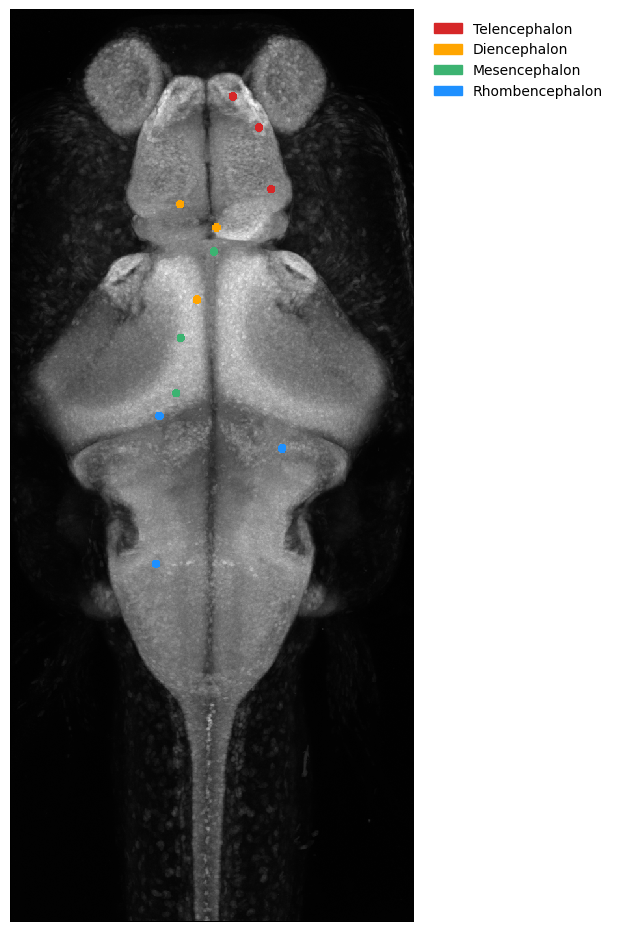

In [18]:
# Build an RGB image: grayscale brain background + a colored dot per selected cell
# Cells are already in z-brain coordinates, so they map directly onto the projection

dot_radius = 7   # radius of each cell marker in pixels

base    = reference_projection / np.max(reference_projection)
roi_map = np.repeat((base * 255).astype(np.uint8)[..., None], 3, axis=2)   # (y, x, 3)

for i in range(len(sel_df)):
    x = float(sel_df['x'].iloc[i])
    y = float(sel_df['y'].iloc[i])
    m = sel_df['major_region'].iloc[i]
    col = (np.array(mcolors.to_rgb(major_region_colors.get(m, 'gray'))) * 255).astype(np.uint8)
    rr, cc = disk((y, x), dot_radius, shape=reference_projection.shape)
    roi_map[rr, cc] = col

fig, ax = plt.subplots(figsize=(6, 12))
ax.imshow(roi_map, interpolation='nearest')
ax.set_axis_off()

handles = [mpatches.Patch(color=major_region_colors[m], label=m) for m in present_majors]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1.0),
          loc='upper left', frameon=False)

plt.tight_layout()